# Collecte des données
**Sources :** OpenMeteo (météo horaire) + yfinance (finance)

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
# chargement de congiguration file

with open('../configs/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
print(f"Période : {cfg['data']['start_date']} -> {cfg['data']['end_date']}")
print(f"Localisation : {cfg['openmeteo']['latitude']}°N, {cfg['openmeteo']['longitude']}°E, Paris")
print(f"Variables météo : {cfg['openmeteo']['variables']}")

Période : 2018-01-01 -> 2024-12-31
Localisation : 48.8566°N, 2.3522°E, Paris
Variables météo : ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'surface_pressure', 'shortwave_radiation', 'cloudcover', 'et0_fao_evapotranspiration']


# Collect OpenMeteo
API historique publique — https://open-meteo.com/en/docs/historical-weather-api

In [3]:
from src.data.data_collect import fetch_openmeteo_data
df_meteo = fetch_openmeteo_data(cfg)
print(f'Shape : {df_meteo.shape}')
df_meteo.head(3)

2026-03-24 01:49:59,506 | INFO     | src.data.data_collect | OpenMeteo : 2018-01-01 -> 2024-12-31
2026-03-24 01:49:59,507 | INFO     | src.data.data_collect | Variables : ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'surface_pressure', 'shortwave_radiation', 'cloudcover', 'et0_fao_evapotranspiration']
2026-03-24 01:50:00,646 | INFO     | httpx | HTTP Request: GET https://archive-api.open-meteo.com/v1/archive?latitude=48.8566&longitude=2.3522&start_date=2018-01-01&end_date=2018-12-31&hourly=temperature_2m&hourly=relative_humidity_2m&hourly=wind_speed_10m&hourly=precipitation&hourly=surface_pressure&hourly=shortwave_radiation&hourly=cloudcover&hourly=et0_fao_evapotranspiration&timezone=Europe%2FParis&wind_speed_unit=ms&precipitation_unit=mm "HTTP/1.1 200 OK"
2026-03-24 01:50:00,767 | INFO     | src.data.data_collect |   2018 : 8760 observations
2026-03-24 01:50:01,551 | INFO     | httpx | HTTP Request: GET https://archive-api.open-meteo.com/v1/archive?lat

Shape : (61368, 8)


,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_precipitation,meteo_surface_pressure,meteo_shortwave_radiation,meteo_cloudcover,meteo_et0_fao_evapotranspiration
datetime,,,,,,,,
2018-01-01 00:00:00,8.1,69,8.61,0.0,1002.2,0.0,2,0.06
2018-01-01 01:00:00,8.1,69,8.20,0.0,1002.5,0.0,1,0.06
2018-01-01 02:00:00,7.8,68,8.23,0.0,1003.4,0.0,59,0.06


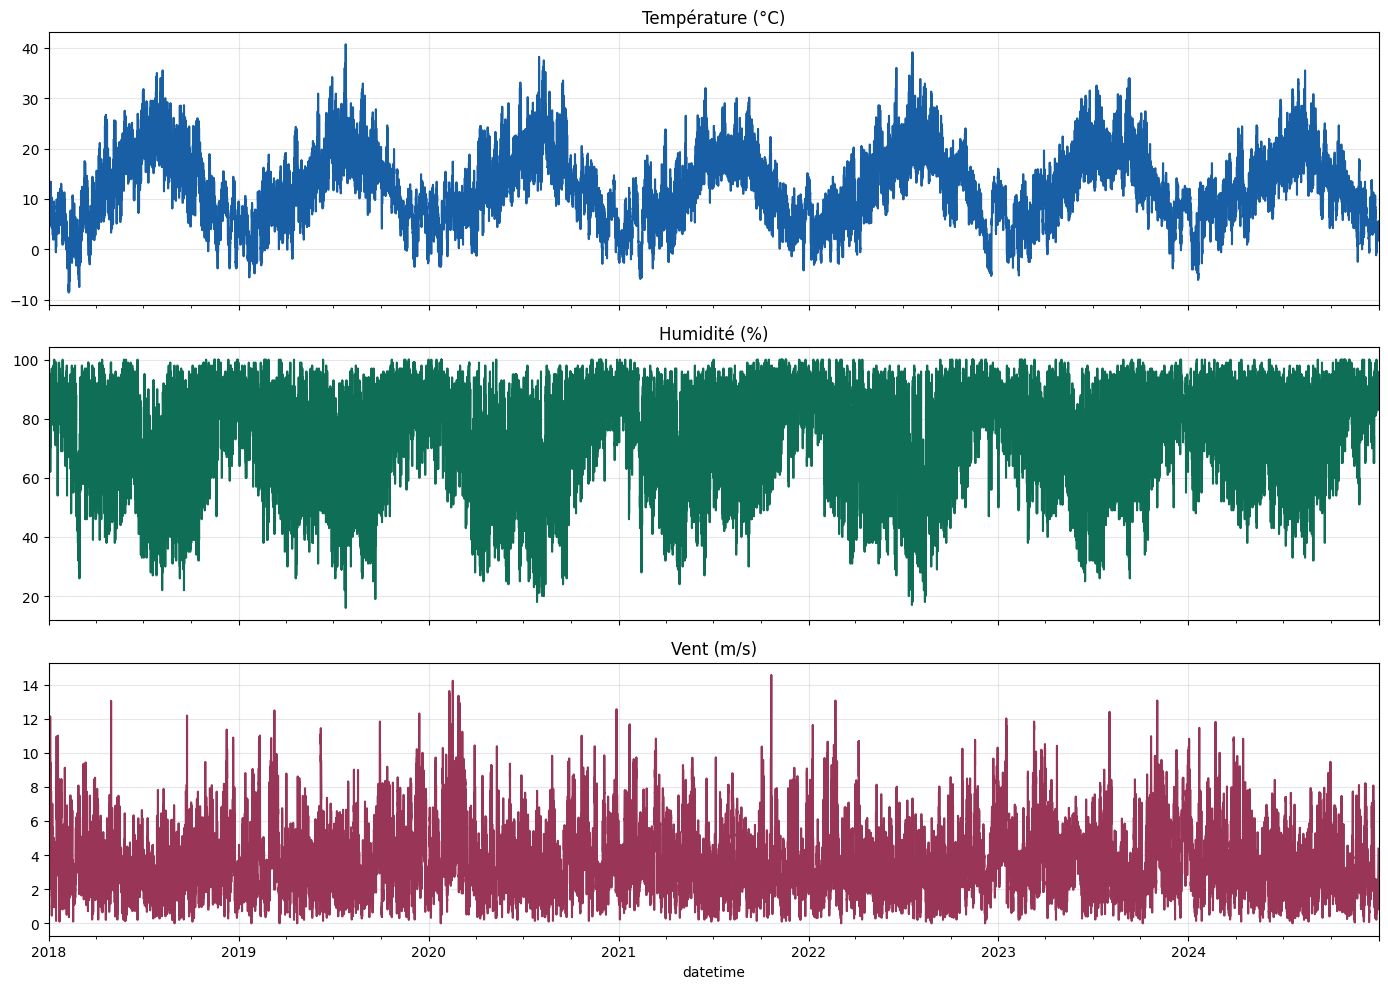

Météo visualisée


In [4]:
# Visualisation rapide
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df_meteo['meteo_temperature_2m'].plot(ax=axes[0], title='Température (°C)', color='#185FA5')
df_meteo['meteo_relative_humidity_2m'].plot(ax=axes[1], title='Humidité (%)', color='#0F6E56')
df_meteo['meteo_wind_speed_10m'].plot(ax=axes[2], title='Vent (m/s)', color='#993556')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/raw_weather_overview.png', dpi=150)
plt.show()
print('Météo visualisée')

# collect yfinance

In [5]:
from src.data.data_collect import fetch_yfinance_data
df_fin = fetch_yfinance_data(cfg)
print(f'Shape : {df_fin.shape}')
df_fin.head(3)

2026-03-24 01:50:08,455 | INFO     | src.data.data_collect | yfinance : ['^FCHI', 'EDF.PA', 'TTE.PA', '^GSPC']
2026-03-24 01:50:08,808 | INFO     | src.data.data_collect | ^FCHI : 61297 observations (horaire)
2026-03-24 01:50:09,284 | ERROR    | yfinance | $EDF.PA: possibly delisted; no timezone found
2026-03-24 01:50:09,290 | ERROR    | yfinance | 
1 Failed download:
2026-03-24 01:50:09,290 | ERROR    | yfinance | ['EDF.PA']: possibly delisted; no timezone found
2026-03-24 01:50:09,293 | WARNING  | src.data.data_collect | EDF.PA : données vides
2026-03-24 01:50:09,450 | INFO     | src.data.data_collect | TTE.PA : 61297 observations (horaire)
2026-03-24 01:50:09,561 | INFO     | src.data.data_collect | ^GSPC : 61297 observations (horaire)
2026-03-24 01:50:09,564 | INFO     | src.data.data_collect | yfinance : 61297 obs | 15 colonnes | Nulls max : 30.5%


Shape : (61297, 15)


,fin_fchi_close,fin_fchi_high,fin_fchi_low,fin_fchi_open,fin_fchi_volume,fin_tte_pa_close,fin_tte_pa_high,fin_tte_pa_low,fin_tte_pa_open,fin_tte_pa_volume,fin_gspc_close,fin_gspc_high,fin_gspc_low,fin_gspc_open,fin_gspc_volume
datetime,,,,,,,,,,,,,,,
2018-01-02 00:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,28.356283,28.568677,28.223921,28.568677,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 01:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,28.356283,28.568677,28.223921,28.568677,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09
2018-01-02 02:00:00,5288.600098,5318.740234,5258.660156,5318.740234,66802600.0,28.356283,28.568677,28.223921,28.568677,4997867.0,2695.810059,2695.889893,2682.360107,2683.72998,3.397430e+09


In [6]:
# Corrélation rapide météo / finance
close_cols = [c for c in df_fin.columns if 'close' in c]
df_daily = pd.concat([df_meteo['meteo_temperature_2m'], df_fin[close_cols]], axis=1).resample('D').mean()
corr = df_daily.corr()
print('Corrélations avec la température :')
print(corr['meteo_temperature_2m'].sort_values(ascending=False))

Corrélations avec la température :
meteo_temperature_2m    1.000000
fin_tte_pa_close        0.016549
fin_gspc_close          0.010517
fin_fchi_close         -0.021558
Name: meteo_temperature_2m, dtype: float64


# Sauvegarde des données brutes

In [10]:
from src.data.data_collect import collect_all_data
results = collect_all_data('../configs/config.yaml')
print('Données sauvegardées')
for name, df in results.items():
    print(f'  {name}: {df.shape}')

2026-03-24 01:54:45,521 | INFO     | src.data.data_collect | ==================================================
2026-03-24 01:54:45,522 | INFO     | src.data.data_collect | COLLECTE DES DONNÉES
2026-03-24 01:54:45,522 | INFO     | src.data.data_collect |   Période      : 2018-01-01 -> 2024-12-31
2026-03-24 01:54:45,523 | INFO     | src.data.data_collect |   Localisation : (48.8566, 2.3522)
2026-03-24 01:54:45,523 | INFO     | src.data.data_collect | ==================================================
2026-03-24 01:54:45,523 | INFO     | src.data.data_collect | OpenMeteo : 2018-01-01 -> 2024-12-31
2026-03-24 01:54:45,524 | INFO     | src.data.data_collect | Variables : ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'surface_pressure', 'shortwave_radiation', 'cloudcover', 'et0_fao_evapotranspiration']
2026-03-24 01:54:46,379 | INFO     | httpx | HTTP Request: GET https://archive-api.open-meteo.com/v1/archive?latitude=48.8566&longitude=2.3522&start_date=2018-

Données sauvegardées
  meteo: (61368, 8)
  finance: (61297, 15)
